# Component 1 — GIK Catalog & IceChunk Virtual Store

C1 ingests GIK Parquet key-reference files produced by ECMWF IFS ensemble output
and commits them as virtual Zarr arrays into an IceChunk store with full time-travel support.

**Key classes**: `GIKCatalog`, `IceChainStore`

In [ ]:
import sys, shutil, subprocess

py_ver = f"{sys.version_info.major}.{sys.version_info.minor}"
assert sys.version_info >= (3, 12), f"Python >= 3.12 required, got {py_ver}"
print(f"OK  Python {py_ver}")

if not shutil.which("uv"):
    subprocess.check_call(["pip", "install", "-q", "uv"])
print("OK  uv")

print("INFO Installing eccodes system library ...")
subprocess.run(["sudo", "apt-get", "update", "-qq"], capture_output=True)
r = subprocess.run(["sudo", "apt-get", "install", "-y", "-qq", "libeccodes0", "libeccodes-tools"],
                   capture_output=True)
if r.returncode != 0:  # newer Ubuntu renames the runtime package
    r2 = subprocess.run(["sudo", "apt-get", "install", "-y", "-qq", "libeccodes0t64", "libeccodes-tools"],
                        capture_output=True)
    if r2.returncode != 0:
        print("WARN  eccodes not installable via apt (no root?) — skipping system install")
print("OK  eccodes")

In [12]:
import os
from pathlib import Path

REPO_URL = "https://github.com/hashirama21/gik-icechain.git"
BRANCH   = "develop"
REPO_DIR = Path("/content/gik-icechain")

if not (REPO_DIR / "pyproject.toml").exists():
    print(f"INFO Cloning (branch: {BRANCH}) ...")
    subprocess.check_call(["git", "clone", "--depth", "1", "--branch", BRANCH,
                           REPO_URL, str(REPO_DIR)])
os.chdir(REPO_DIR)
print(f"OK  Working directory: {Path.cwd()}")

OK  Working directory: /content/gik-icechain


In [13]:
print("INFO uv sync (installs all dependencies) ...")
subprocess.check_call(["uv", "sync"], stdout=subprocess.DEVNULL)
r = subprocess.run(["uv", "run", "gik-icechain", "--help"], capture_output=True)
print("OK  CLI gik-icechain accessible" if r.returncode == 0 else "FAIL CLI not working")

INFO uv sync (installs all dependencies) ...
OK  CLI gik-icechain accessible


In [ ]:
import os
from pathlib import Path
from datetime import date
import sys
import subprocess

try:
    from google.colab import userdata as _colab_userdata
except ImportError:
    _colab_userdata = None

# Ensure REPO_DIR is defined
REPO_DIR = Path("/content/gik-icechain")
SRC_DIR = REPO_DIR / "src"

# Install the package in editable mode
if REPO_DIR.exists():
    print("INFO Installing gik-icechain...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", str(REPO_DIR)])

# The module is inside the 'src' directory
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from gik_icechain.shared.config import load_config

def get_secret(name: str, default: str = "") -> str:
    if _colab_userdata is not None:
        try:
            v = _colab_userdata.get(name)
            if v:
                return v
        except Exception:
            pass
    return os.environ.get(name, default)

# Fetching MinIO/S3 secrets
AWS_ENDPOINT = get_secret("AWS_ENDPOINT_URL")
AWS_KEY      = get_secret("AWS_ACCESS_KEY_ID")
AWS_SECRET   = get_secret("AWS_SECRET_ACCESS_KEY")
HF_TOKEN     = get_secret("HF_TOKEN")
EARTHDATA_U  = get_secret("EARTHDATA_USER")
EARTHDATA_P  = get_secret("EARTHDATA_PASSWORD")

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
if EARTHDATA_U:
    os.environ["EARTHDATA_USER"] = EARTHDATA_U
    os.environ["EARTHDATA_PASSWORD"] = EARTHDATA_P

LIVE = bool(AWS_ENDPOINT and AWS_KEY and AWS_SECRET)
OUTPUT = Path("results/e2e_colab")

if LIVE:
    os.environ["AWS_ENDPOINT_URL"]      = AWS_ENDPOINT
    os.environ["AWS_ACCESS_KEY_ID"]     = AWS_KEY
    os.environ["AWS_SECRET_ACCESS_KEY"] = AWS_SECRET
    os.environ["AWS_REGION"]            = "us-east-1"
    CONFIG = REPO_DIR / "configs/default.yaml"
    print(f" LIVE mode — Data will be written to: {AWS_ENDPOINT}")
else:
    local_cfg = f"""outputs:
  icechunk_store_uri: \"{str(REPO_DIR / OUTPUT / 'icechunk-store')}\"
  icechunk_store_region: \"eu-west-1\"
  endpoint_url: \"\"
  exceedance_store_uri: \"{str(REPO_DIR / OUTPUT / 'exceedance-zarr')}\"
  exceedance_icechunk_uri: \"\"
  risk_icechunk_uri: \"\"
  risk_output_dir: \"{str(OUTPUT / 'admin1_risk')}/\"
"""
    config_path = REPO_DIR / "configs/colab_e2e.yaml"
    config_path.parent.mkdir(parents=True, exist_ok=True)
    config_path.write_text(local_cfg)
    CONFIG = config_path
    print(" LOCAL mode — Secrets not found. Using local Colab filesystem.")

# Load the configuration object
cfg = load_config(Path(CONFIG))
print(f"Target Config: {CONFIG}")
print(f"Config loaded successfully.")

## 1.1 GIK Catalog

In [22]:
START = date(2025, 1, 1)
END   = date(2025, 1, 2)
print(f"Config loaded — endpoint: {cfg.outputs.endpoint_url}")
print(f"Demo window: {START} → {END}")

from gik_icechain.conversion.gik_loader import GIKCatalog

catalog = GIKCatalog(
    cfg.sources.gik_hf_dataset,
    catalog_file=cfg.sources.gik_catalog_file,
)
cat_df = catalog.load_catalog()
print(f"Catalog rows  : {len(cat_df)}")
print(f"Date range    : {cat_df['date'].min()} → {cat_df['date'].max()}")
print(cat_df.head(3))

paths = catalog.get_parquet_paths(start=START, end=END, run_hours=(0,), variables=["tp"])
print(f"\nParquet paths for {START} run-00Z tp: {len(paths)}")

Config loaded — endpoint: 
Demo window: 2025-01-01 → 2025-01-02
2026-06-12 08:38:09 [info     ] loading_gik_catalog            path=datasets/E4DRR/gik-ecmwf-par/catalog.parquet


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


2026-06-12 08:38:11 [info     ] gik_catalog_loaded             date_range='20240301 to 20260218' rows=144228
Catalog rows  : 144228
Date range    : 20240301 → 20260218
   year month      date  run   member                     filename  \
0  2024    03  20240301  00z  control  2024030100z-control.parquet   
1  2024    03  20240301  00z   ens_01   2024030100z-ens_01.parquet   
2  2024    03  20240301  00z   ens_02   2024030100z-ens_02.parquet   

                                             hf_path  size_bytes _date_parsed  
0  run_par_ecmwf/2024/03/20240301/00z/2024030100z...       94548   2024-03-01  
1  run_par_ecmwf/2024/03/20240301/00z/2024030100z...       94640   2024-03-01  
2  run_par_ecmwf/2024/03/20240301/00z/2024030100z...       94603   2024-03-01  
2026-06-12 08:38:12 [info     ] catalog_variable_filter_note   msg='Catalog indexes whole files; per-file filter applied by VirtualiZarr.' variables=['tp']
2026-06-12 08:38:12 [info     ] parquet_paths_resolved         count=102 da

## 1.2 IceChunk store — snapshots

In [23]:
from gik_icechain.conversion.icechunk_writer import IceChainStore

store = IceChainStore(
    cfg.outputs.icechunk_store_uri,
    region=cfg.outputs.icechunk_store_region,
    endpoint_url=cfg.outputs.endpoint_url,
)
store.create_or_open()

snapshots = store.list_snapshots()
snap_df = pd.DataFrame(snapshots)
print(snap_df.to_string(index=False))
print(f"\nTotal snapshots: {len(snap_df)}")

2026-06-12 08:38:24 [info     ] icechunk_minio_endpoint        bucket=gik-icechain endpoint=http://20.116.218.195:9000
2026-06-12 08:38:24 [info     ] icechunk_manifest_splitting    dim=step size=1000
2026-06-12 08:38:24 [info     ] icechunk_store_ready           uri=s3://gik-icechain/gik-icechain-store
           tag       commit forecast_date                      commit_time                    message
2024-04-24T00Z JRQ1DE6Y1J86    2024-04-24 2026-06-09T11:09:59.574707+00:00 GIK ingest: 2024-04-24T00Z
2024-04-25T00Z ZEY16DG7RGXP    2024-04-25 2026-06-11T15:53:53.597104+00:00 GIK ingest: 2024-04-25T00Z
2024-04-26T00Z FN0VXPNV8614    2024-04-26 2026-06-04T16:11:56.617650+00:00 GIK ingest: 2024-04-26T00Z
2024-10-01T00Z Q0C65DYM1NDM    2024-10-01 2026-05-31T01:47:13.558219+00:00 GIK ingest: 2024-10-01T00Z
2024-10-02T00Z Q6HRTRF6WM69    2024-10-02 2026-06-03T15:49:12.598071+00:00 GIK ingest: 2024-10-02T00Z
2024-10-03T00Z PXCN8JWGQA43    2024-10-03 2026-06-03T15:49:30.815547+00:00 GIK inge

## 1.3 Checkout a forecast day

In [24]:
ds = store.checkout_as_of(START)
print(ds)
print(f"\ntp shape: {ds['tp'].shape}")
print(f"Members: {ds.sizes['member']}, Steps: {ds.sizes['step']}")

2026-06-12 08:38:45 [info     ] time_travel_checkout           as_of_date=2025-01-01 resolved_tag=2025-01-01T00Z snapshot=45V2Y08W62JB
<xarray.Dataset> Size: 90GB
Dimensions:  (member: 51, step: 85, latitude: 721, longitude: 1440)
Coordinates:
  * member   (member) int64 408B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * step     (step) timedelta64[ns] 680B 0 days 00:00:00 ... 15 days 00:00:00
Dimensions without coordinates: latitude, longitude
Data variables:
    2t       (member, step, latitude, longitude) float32 18GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    10v      (member, step, latitude, longitude) float32 18GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    tp       (member, step, latitude, longitude) float32 18GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    ro       (member, step, latitude, longitude) float32 18GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    10u      (member, step, latitude, longitude) float3

/content/gik-icechain/src/gik_icechain/conversion/icechunk_writer.py:245: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_zarr(session.store, group=target_date, consolidated=False)


## 1.4 Store validation

In [25]:
report = store.validate()
print(report)
print(f"Committed days: {report['committed_days']}  |  gaps: {report['gaps_detected']}")
# A production store should report gaps_detected == 0; the dev store may be sparse.


2026-06-12 08:39:00 [info     ] store_opened_latest            date=2025-12-15 dims={'member': 51, 'step': 85, 'latitude': 721, 'longitude': 1440}


/content/gik-icechain/src/gik_icechain/conversion/icechunk_writer.py:265: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_zarr(session.store, group=latest_date, consolidated=False)


2026-06-12 08:39:02 [info     ] store_validation               committed_days=48 date_range='2024-04-24 to 2025-12-15' gaps_detected=13 total_snapshots=48 variables_present=['10u', 'ro', '10v', '2t', 'tp']
{'committed_days': 48, 'date_range': '2024-04-24 to 2025-12-15', 'gaps_detected': 13, 'gap_details': ['2024-04-26 -> 2024-10-01', '2024-10-07 -> 2024-10-15', '2024-10-15 -> 2024-12-01', '2024-12-01 -> 2024-12-13', '2024-12-13 -> 2025-01-01', '2025-01-07 -> 2025-01-13', '2025-01-19 -> 2025-01-27', '2025-01-27 -> 2025-02-22', '2025-02-28 -> 2025-04-20', '2025-04-20 -> 2025-10-24'], 'variables_present': ['10u', 'ro', '10v', '2t', 'tp'], 'total_snapshots': 48}
Committed days: 48  |  gaps: 13


## 1.5 Time-travel comparison

In [26]:
ds_jan1 = store.checkout_as_of(date(2025, 1, 1))
ds_jan7 = store.checkout_as_of(date(2025, 1, 7))
print(f"Jan 1 tp mean: {float(ds_jan1['tp'].mean()):.5f} m")
print(f"Jan 7 tp mean: {float(ds_jan7['tp'].mean()):.5f} m")

2026-06-12 08:39:11 [info     ] time_travel_checkout           as_of_date=2025-01-01 resolved_tag=2025-01-01T00Z snapshot=45V2Y08W62JB
2026-06-12 08:39:11 [info     ] time_travel_checkout           as_of_date=2025-01-07 resolved_tag=2025-01-07T00Z snapshot=0AQ2DDF45MCX


/content/gik-icechain/src/gik_icechain/conversion/icechunk_writer.py:245: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_zarr(session.store, group=target_date, consolidated=False)
/content/gik-icechain/src/gik_icechain/conversion/icechunk_writer.py:245: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a t

Jan 1 tp mean: 0.01508 m
Jan 7 tp mean: 0.01583 m


## 1.6 Visualize ensemble spread (step=4, first member vs last member)

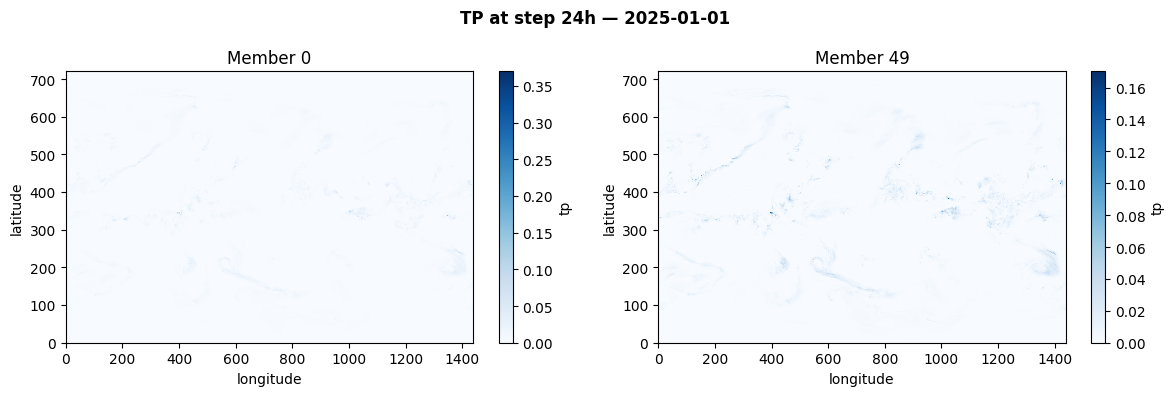

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ds_jan1["tp"].isel(step=4, member=0).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Member 0")
ds_jan1["tp"].isel(step=4, member=-1).plot(ax=axes[1], cmap="Blues")
axes[1].set_title("Member 49")
fig.suptitle("TP at step 24h — 2025-01-01", fontweight="bold")
fig.tight_layout()
plt.show()

### 1.7 Statistical Distribution (Histogram)
Comparing the frequency distribution of precipitation values across different ensemble members helps identify outliers and the range of uncertainty.

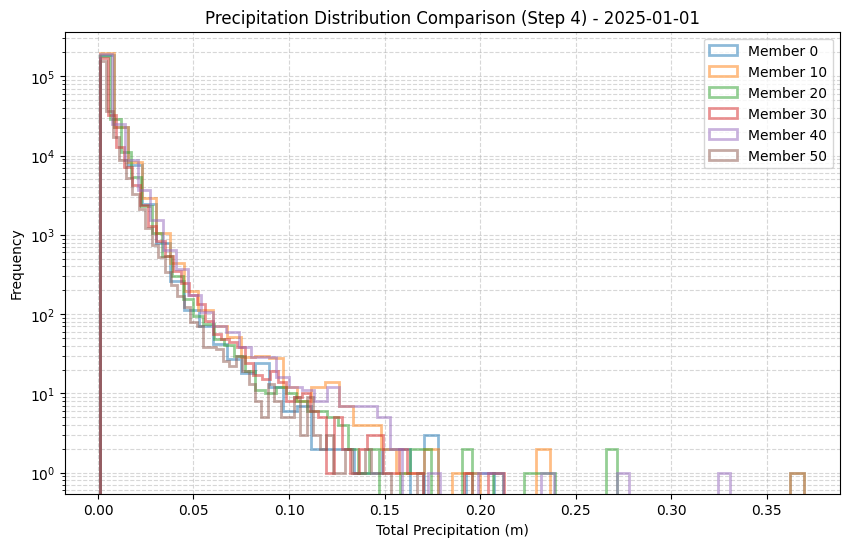

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Select a specific time step (e.g., index 4 which corresponds to 24h)
step_idx = 4
members_to_compare = [0, 10, 20, 30, 40, 50]

plt.figure(figsize=(10, 6))

for m in members_to_compare:
    # Flatten the 2D spatial data for the histogram
    data = ds_jan1["tp"].isel(step=step_idx, member=m).values.flatten()
    # Exclude zero values to focus on where precipitation is actually occurring
    precip_values = data[data > 0.001]

    plt.hist(precip_values, bins=50, alpha=0.5, label=f'Member {m}', histtype='step', linewidth=2)

plt.title(f"Precipitation Distribution Comparison (Step {step_idx}) - 2025-01-01")
plt.xlabel("Total Precipitation (m)")
plt.ylabel("Frequency")
plt.yscale('log')  # Log scale often helps visualize weather extremes better
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()